<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EC%86%A1%EC%9E%AC%ED%98%84/ELEalgo_MLP%EC%9D%98_%EC%82%AC%EB%B3%B8_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Load
실험 Dataset: California housing

In [8]:
import pandas as pd

CSV_FILEPATH = "/content/merged_features_25C.csv"
df = pd.read_csv(CSV_FILEPATH)

print("데이터 크기 (행, 열):", df.shape)
print("\n컬럼 목록:")
for col in df.columns:
    print(" -", col)

df.head()

데이터 크기 (행, 열): (141, 29)

컬럼 목록:
 - cell_global_id
 - rpt_id
 - aging_condition
 - variance
 - xmean
 - mean3839
 - mean3940
 - mean4041
 - mean4142
 - max
 - min
 - range
 - stdev
 - dcirohm
 - dcir_soc00ohm
 - dcir_soc10ohm
 - dcir_soc20ohm
 - dcir_soc30ohm
 - dcir_soc40ohm
 - dcir_soc50ohm
 - dcir_soc60ohm
 - dcir_soc70ohm
 - dcir_soc80ohm
 - deltat023840
 - deltat103840
 - ctr
 - ccct
 - cvct
 - soh_label_pct


,cell_global_id,rpt_id,aging_condition,variance,xmean,mean3839,mean3940,mean4041,mean4142,max,...,dcir_soc50ohm,dcir_soc60ohm,dcir_soc70ohm,dcir_soc80ohm,deltat023840,deltat103840,ctr,ccct,cvct,soh_label_pct
0,1,0,LOW C@ 25°C #1,0.007519,0.294405,0.238540,0.287085,0.247514,0.409893,0.463239,...,0.025000,0.025000,0.021667,0.023333,4140.0,793.333333,0.191626,3140,443.05,100.000000
1,1,1,LOW C@ 25°C #1,0.008914,0.298118,0.253707,0.288757,0.239441,0.416074,0.471264,...,0.026667,0.025000,0.023333,0.023333,4050.0,786.666667,0.194239,2870,455.05,93.108019
2,1,2,LOW C@ 25°C #1,0.009736,0.302310,0.258539,0.295900,0.244835,0.415268,0.472016,...,0.028333,0.026667,0.025000,0.025000,4020.0,770.000000,0.191542,2720,458.15,89.463221
3,1,3,LOW C@ 25°C #1,0.010022,0.302330,0.259584,0.297045,0.245275,0.412607,0.469879,...,0.030000,0.026667,0.026667,0.025000,4000.0,765.000000,0.191250,2650,460.65,87.773360
4,1,4,LOW C@ 25°C #1,0.010921,0.311753,0.267694,0.308545,0.256374,0.419489,0.478524,...,0.030000,0.026667,0.028333,0.028333,4000.0,755.000000,0.188750,2570,475.70,86.249172


# Config

* 라이브러리 불러오기
* hyperparameter 조정

In [9]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


# hyperparamter 조정
CONFIG = {
    "batch_size": 5,
    "epochs": 1000,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "patience": 10,
    "random_seed": 42
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(CONFIG["random_seed"])

# 기본 실행 코드
MLP 구조: N -> 16 -> 8 ->1

In [10]:
# 데이터셋 클래스 (CSV 파일 읽기)
class BatteryCSVDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# MLP 모델 클래스
class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# Dataset Loader
*   Feature, Target 설정
*   Dataset Split: Train 8 / Val 1 / Test 1




In [11]:
CSV_FILENAME = "merged_features_25C.csv"

# Feature, Target 설정
FEATURES = ["ccct", "variance", "dcirohm", "deltat023840", "ctr"]
TARGET = "soh_label_pct"

df = pd.read_csv(CSV_FILENAME)

X = df[FEATURES].values
y = df[TARGET].values

# Dataset Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=CONFIG["random_seed"])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=CONFIG["random_seed"])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = BatteryCSVDataset(X_train, y_train)
val_dataset = BatteryCSVDataset(X_val, y_val)
test_dataset = BatteryCSVDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

# Train/Val/Test 별 Data 개수 출력
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 112
Validation: 14
Test: 15


# Epoch 실행

*   Loss: MSE
*   Optimizer: Adam
*   Weight decay 적용: overfitting 방지
*   Learning rate Scheduler: 기준 5번
*   Early Stopping: 기준 Config에서 설정





In [12]:
model = SOHPredictorMLP(input_dim=len(FEATURES))

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"])

# Learning rate Schedler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
patience_count = 0

train_losses = []
val_losses = []

# Epoch 실행
for epoch in range(1, CONFIG["epochs"] + 1):

    model.train()
    train_loss = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred_y = model(batch_x)
        loss = criterion(pred_y, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:
            pred_y = model(batch_x)
            loss = criterion(pred_y, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    # best validation 값 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        patience_count = 0

        torch.save(
            model.state_dict(),
            "best_mlp_model.pth")
    else:
        patience_count += 1

    # Early Stopping -> 기준 config에서 설정
    if patience_count >= CONFIG["patience"]:
        print("Early stopping")
        break

Epoch [1/1000] Train Loss: 7839.4208 Val Loss: 7664.2749
Epoch [2/1000] Train Loss: 7820.0507 Val Loss: 7643.1629
Epoch [3/1000] Train Loss: 7765.6414 Val Loss: 7613.7559
Epoch [4/1000] Train Loss: 7733.5966 Val Loss: 7572.4209
Epoch [5/1000] Train Loss: 7695.4457 Val Loss: 7514.1903
Epoch [6/1000] Train Loss: 7649.5609 Val Loss: 7432.2409
Epoch [7/1000] Train Loss: 7562.4657 Val Loss: 7314.9860
Epoch [8/1000] Train Loss: 7382.8807 Val Loss: 7149.5205
Epoch [9/1000] Train Loss: 7176.5066 Val Loss: 6914.7931
Epoch [10/1000] Train Loss: 6869.0040 Val Loss: 6599.3337
Epoch [11/1000] Train Loss: 6537.2521 Val Loss: 6204.0964
Epoch [12/1000] Train Loss: 6103.9099 Val Loss: 5741.1673
Epoch [13/1000] Train Loss: 5574.7918 Val Loss: 5209.2983
Epoch [14/1000] Train Loss: 4964.0437 Val Loss: 4620.6702
Epoch [15/1000] Train Loss: 4354.4983 Val Loss: 4008.2264
Epoch [16/1000] Train Loss: 3761.8266 Val Loss: 3414.9267
Epoch [17/1000] Train Loss: 3115.4559 Val Loss: 2886.7312
Epoch [18/1000] Train L

# Loss Curve




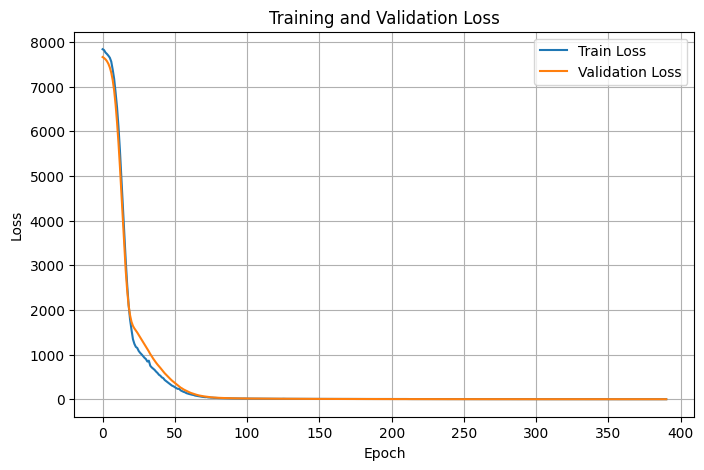

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss")

plt.plot(
    val_losses,
    label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

# Result

Test Loss: 0.416

Prediction Result
    Actual  Prediction  Absolute Error  Error Rate (%)
100.000000  100.148804          0.1488            0.15
100.000000  100.218597          0.2186            0.22
 83.449402   83.884903          0.4355            0.52
 86.279701   85.449898          0.8298            0.96
 86.160400   86.910202          0.7498            0.87
 85.138702   85.288597          0.1499            0.18
 88.010498   88.467400          0.4568            0.52
 89.475403   89.504700          0.0293            0.03
 93.386002   92.519096          0.8669            0.93
 93.295700   92.226303          1.0694            1.15

=== 1. 모델 정확도 (Test Set 전체 15개) ===
MSE       : 0.4160
MAE       : 0.5360 %p
RMSE      : 0.6450 %p
Max Error : 1.2093 %p
R² Score  : 0.9907

=== 2. 모델 간편성 ===
구조: N(5) -> 16 -> 8 -> 1, ReLU
총 파라미터 수: 241개


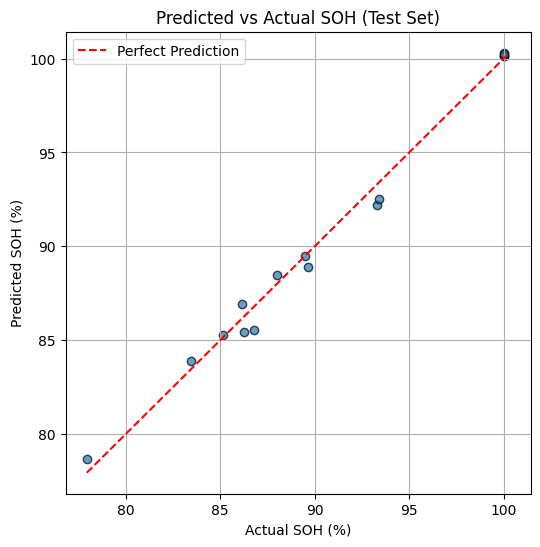

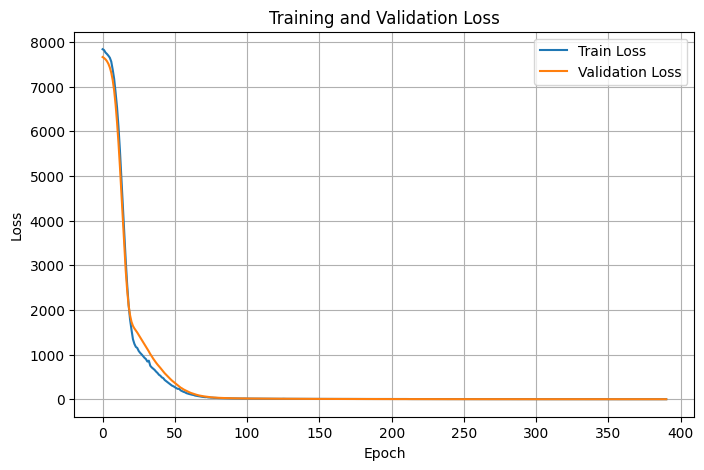

/tmp/ipykernel_6235/226232876.py:111: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6235/226232876.py:111: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


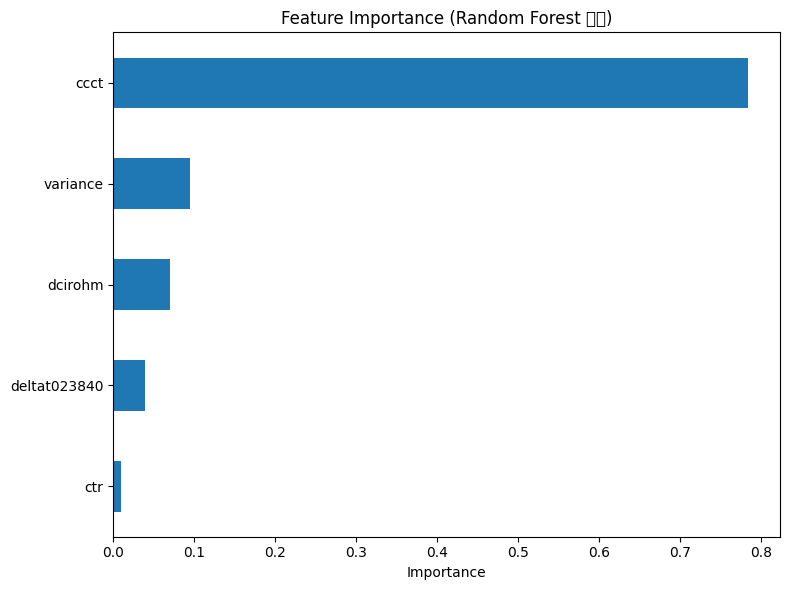


=== 4. 모델 속도 ===
Test Set(15개) 1회 추론 평균 시간: 0.1368 ms
샘플 1개당 평균 시간: 0.0091 ms


In [14]:
model.load_state_dict(torch.load("best_mlp_model.pth"))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        pred_y = model(batch_x)

        predictions.extend(pred_y.numpy().flatten())
        actuals.extend(batch_y.numpy().flatten())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Test Loss
test_loss = mean_squared_error(actuals, predictions)

print("Test Loss:", round(test_loss, 4))

# 무작위 10개 결과 확인
random_indices = np.random.choice(
    len(actuals),
    size=10,
    replace=False
)

sample_actuals = actuals[random_indices]
sample_predictions = predictions[random_indices]

abs_error = np.abs(sample_actuals - sample_predictions)
error_rate_pct = (abs_error / np.maximum(np.abs(sample_actuals), 1e-8)) * 100

result_df = pd.DataFrame({
    "Actual": np.round(sample_actuals, 4),
    "Prediction": np.round(sample_predictions, 4),
    "Absolute Error": np.round(abs_error, 4),
    "Error Rate (%)": np.round(error_rate_pct, 2)})

print("\nPrediction Result")
print(result_df.to_string(index=False))

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 모델 정확도 (MSE는 이미 위에 있음 -> MAE, RMSE, R², Max Error 추가)
# ==========================================
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)
max_err = np.max(np.abs(actuals - predictions))

print("\n=== 1. 모델 정확도 (Test Set 전체 15개) ===")
print(f"MSE       : {test_loss:.4f}")
print(f"MAE       : {mae:.4f} %p")
print(f"RMSE      : {rmse:.4f} %p")
print(f"Max Error : {max_err:.4f} %p")
print(f"R² Score  : {r2:.4f}")

# ==========================================
# 2. 모델 간편성/이해도
# ==========================================
total_params = sum(p.numel() for p in model.parameters())
print(f"\n=== 2. 모델 간편성 ===")
print(f"구조: N({len(FEATURES)}) -> 16 -> 8 -> 1, ReLU")
print(f"총 파라미터 수: {total_params}개")

# ==========================================
# 3-1. Predicted vs Actual Plot
# ==========================================
plt.figure(figsize=(6, 6))
plt.scatter(actuals, predictions, alpha=0.7, edgecolors='k')
min_v, max_v = min(actuals.min(), predictions.min()), max(actuals.max(), predictions.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='Perfect Prediction')
plt.xlabel('Actual SOH (%)')
plt.ylabel('Predicted SOH (%)')
plt.title('Predicted vs Actual SOH (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 3-2. Loss Curve (이미 있는 train_losses, val_losses 재사용)
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 3-3. Feature Importance (Random Forest로 대체 측정)
# ==========================================
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=CONFIG["random_seed"])
rf.fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest 기준)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ==========================================
# 4. 모델 속도 (추론 시간)
# ==========================================
n_repeat = 100
x_sample = torch.tensor(X_test, dtype=torch.float32)
start = time.time()
for _ in range(n_repeat):
    with torch.no_grad():
        _ = model(x_sample)
elapsed = (time.time() - start) / n_repeat

print(f"\n=== 4. 모델 속도 ===")
print(f"Test Set({len(X_test)}개) 1회 추론 평균 시간: {elapsed*1000:.4f} ms")
print(f"샘플 1개당 평균 시간: {elapsed*1000/len(X_test):.4f} ms")